<a href="https://colab.research.google.com/github/mmkinfo25-prog/python/blob/main/Reg_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import scipy.stats as st
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
PATH = "/content/drive/MyDrive/AIES/Faculty_Experience_Salary_Linear_Regression.csv"
df = pd.read_csv(PATH)


In [3]:
print("Shape:", df.shape)
print("Missing values:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (30, 3)
Missing values:
 Faculty_ID          0
Experience_Years    0
Salary_Lakhs        0
dtype: int64
Duplicate rows: 0


In [4]:
df = df.drop_duplicates().dropna()
df["Experience_Years"] = pd.to_numeric(df["Experience_Years"], errors="coerce")
df["Salary_Lakhs"] = pd.to_numeric(df["Salary_Lakhs"], errors="coerce")
df = df.dropna()

In [5]:
for c in ["Experience_Years", "Salary_Lakhs"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()
    print(f"IQR outliers in {c}: {n}")

IQR outliers in Experience_Years: 0
IQR outliers in Salary_Lakhs: 0


In [6]:
X = df[["Experience_Years"]]
y = df["Salary_Lakhs"]
print("\nCorrelation:", round(df["Experience_Years"].corr(df["Salary_Lakhs"]), 4))


Correlation: 0.9981


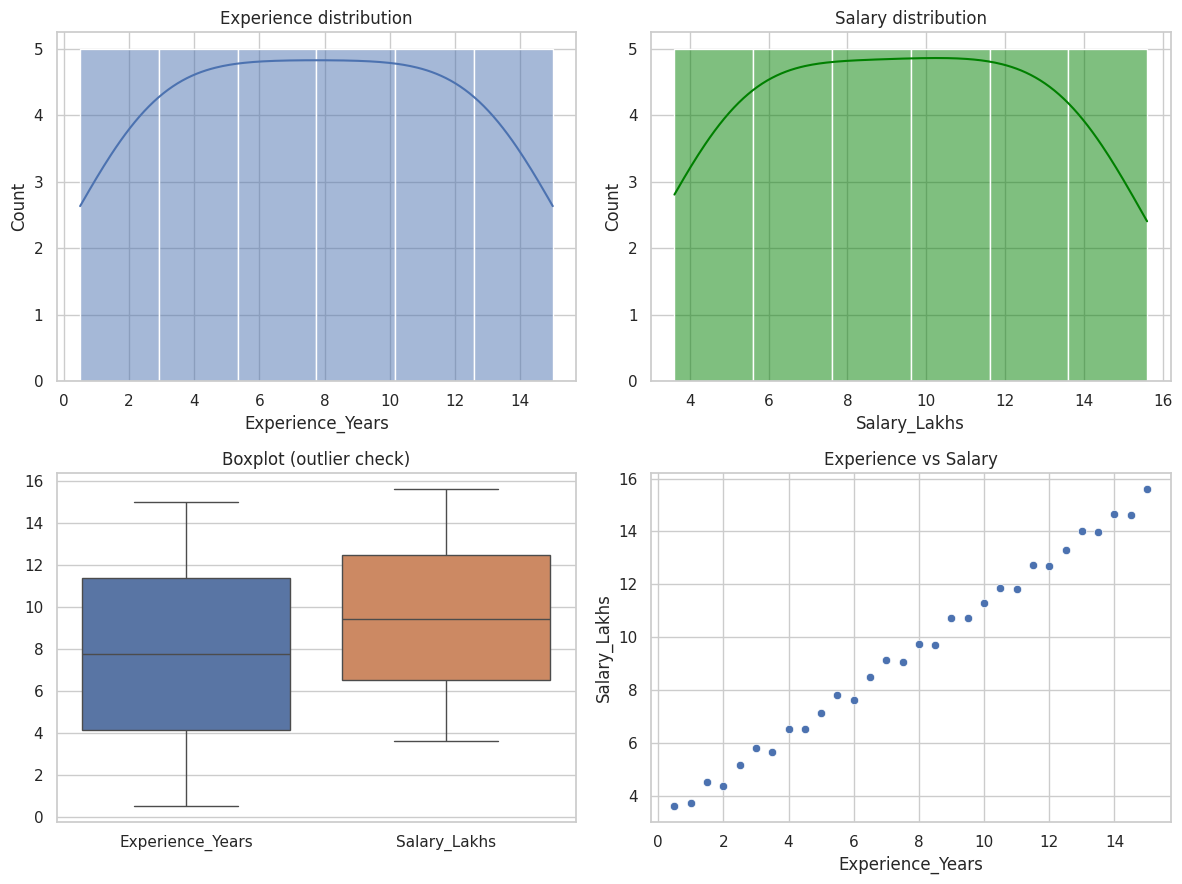

In [7]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
sns.histplot(df["Experience_Years"], kde=True, ax=ax[0, 0])
ax[0, 0].set_title("Experience distribution")
sns.histplot(df["Salary_Lakhs"], kde=True, ax=ax[0, 1], color="green")
ax[0, 1].set_title("Salary distribution")
sns.boxplot(data=df[["Experience_Years", "Salary_Lakhs"]], ax=ax[1, 0])
ax[1, 0].set_title("Boxplot (outlier check)")
sns.scatterplot(x="Experience_Years", y="Salary_Lakhs", data=df, ax=ax[1, 1])
ax[1, 1].set_title("Experience vs Salary")
plt.tight_layout()
plt.show()

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
def evaluate(model, Xa, ya):
    p = model.predict(Xa)
    return {
        "MAE": round(mean_absolute_error(ya, p), 4),
        "MSE": round(mean_squared_error(ya, p), 4),
        "RMSE": round(float(np.sqrt(mean_squared_error(ya, p))), 4),
        "R2": round(r2_score(ya, p), 4),
    }

In [10]:
lr = LinearRegression().fit(X_tr, y_tr)
print(f"\nSalary = {lr.intercept_:.3f} + {lr.coef_[0]:.3f} x Experience")
print("Train:", evaluate(lr, X_tr, y_tr))
print("Test :", evaluate(lr, X_te, y_te))


Salary = 3.076 + 0.819 x Experience
Train: {'MAE': 0.2062, 'MSE': 0.0524, 'RMSE': 0.2289, 'R2': 0.9961}
Test : {'MAE': 0.1686, 'MSE': 0.0355, 'RMSE': 0.1883, 'R2': 0.9957}


Shapiro-Wilk p-value (residual normality): 0.0206


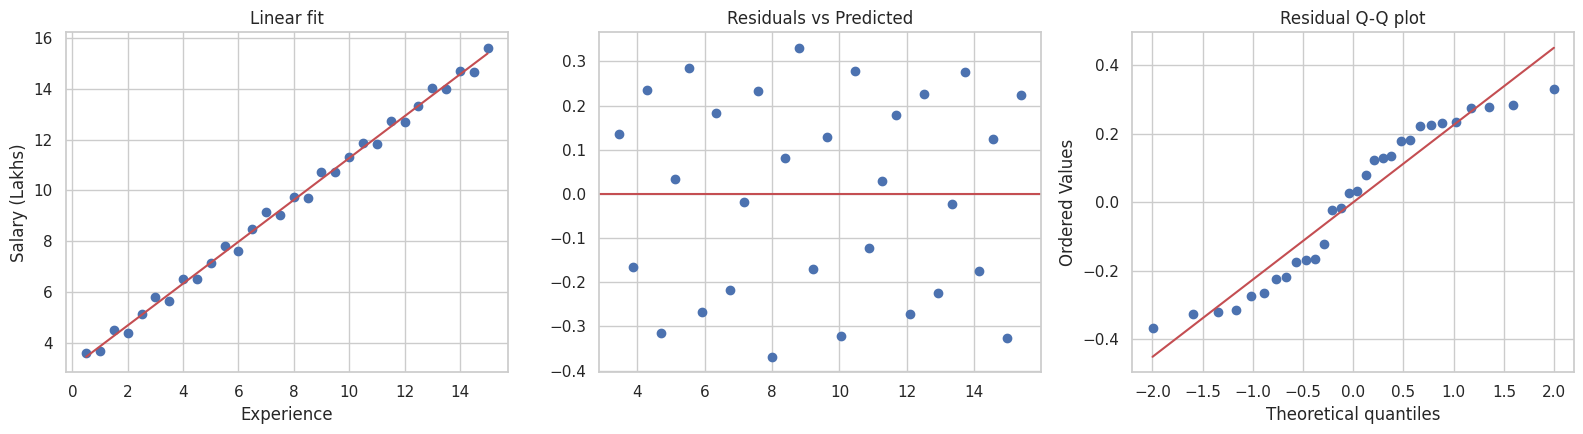

In [11]:
full = LinearRegression().fit(X, y)
pred = full.predict(X)
resid = y - pred
print("Shapiro-Wilk p-value (residual normality):", round(st.shapiro(resid).pvalue, 4))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(X, y)
ax[0].plot(X, pred, "r")
ax[0].set_title("Linear fit")
ax[0].set_xlabel("Experience")
ax[0].set_ylabel("Salary (Lakhs)")
ax[1].scatter(pred, resid)
ax[1].axhline(0, color="r")
ax[1].set_title("Residuals vs Predicted")
st.probplot(resid, plot=ax[2])
ax[2].set_title("Residual Q-Q plot")
plt.tight_layout()
plt.show()

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Linear (deg 1)": LinearRegression(),
    "Polynomial (deg 2)": make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression()),
    "Polynomial (deg 3)": make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression()),
}

rows = []
for name, m in models.items():
    r2 = cross_val_score(m, X, y, cv=kf, scoring="r2").mean()
    rmse = -cross_val_score(m, X, y, cv=kf, scoring="neg_root_mean_squared_error").mean()
    rows.append([name, round(r2, 4), round(rmse, 4)])

result = pd.DataFrame(rows, columns=["Model", "CV_R2", "CV_RMSE"])
print("\n5-fold cross-validation comparison:\n", result.to_string(index=False))



5-fold cross-validation comparison:
              Model  CV_R2  CV_RMSE
    Linear (deg 1) 0.9943   0.2321
Polynomial (deg 2) 0.9942   0.2343
Polynomial (deg 3) 0.9937   0.2455


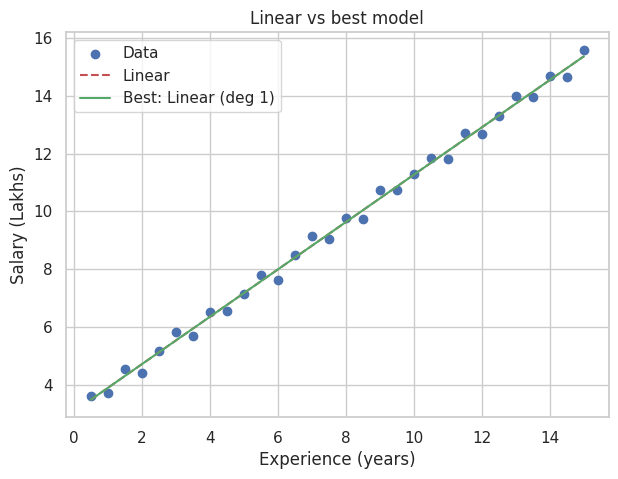

In [13]:
best_name = result.sort_values("CV_RMSE").iloc[0]["Model"]
best = models[best_name].fit(X, y)
xs = pd.DataFrame({"Experience_Years": np.linspace(X["Experience_Years"].min(),
                                                   X["Experience_Years"].max(), 200)})
plt.figure(figsize=(7, 5))
plt.scatter(X, y, label="Data")
plt.plot(xs, full.predict(xs), "r--", label="Linear")
plt.plot(xs, best.predict(xs), "g", label=f"Best: {best_name}")
plt.xlabel("Experience (years)")
plt.ylabel("Salary (Lakhs)")
plt.legend()
plt.title("Linear vs best model")
plt.show()

In [14]:
new = pd.DataFrame({"Experience_Years": [8.0]})
print("Predicted salary for 8 years:", round(float(best.predict(new)[0]), 2), "lakhs")

Predicted salary for 8 years: 9.63 lakhs
